# Trust Attribution Analysis

This notebook analyses behavioural data from the **Humanlike AI Systems and Trust Attribution** experiment.

> **Data note:** `sample_output.json` and `sample_output.csv` are synthetic datasets generated to demonstrate the analysis pipeline. They simulate realistic behavioural patterns (Condition B shows higher reliance and shorter latency) but do not represent real participant data. Replace with live experiment output to run on real data.

**Conditions:**
- **Condition A (System 7):** Neutral system icon, grey palette, formal tone, calibrated confidence
- **Condition B (Alex):** Human initials avatar, warm blue palette, conversational tone, overstated confidence

**Analysis sections:**
1. Setup and imports
2. Load data
3. Reliance rate by condition
4. Override rate by condition
5. Response latency by condition
6. Statistical tests — chi-square + Welch t-test
7. Paired t-test + Cohen's d (within-subjects validation)
8. Confidence calibration — participant trust vs AI accuracy
9. Stakes × condition interaction
10. Trust drift — reliance and latency by block position
11. Self-reported trust scale
12. Summary table
13. Within-person trust shift *(unique to within-subjects design)*
14. Domain-specific analysis — where is the cue effect strongest?
15. Final summary report

In [1]:
%pip install --upgrade numpy pandas scipy scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1 · Setup and imports

In [2]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.facecolor': '#fafafa',
    'axes.facecolor':   '#fafafa',
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

COLORS = {'A': '#6b7280', 'B': '#2563eb'}
LABELS = {'A': 'System 7 (Neutral)', 'B': 'Alex (Humanlike)'}
AI_ACCURACY = {'t1': 0.72, 't2': 0.68, 't3': 0.75, 't4': 0.70, 't5': 0.65, 't6': 0.73}

def cohen_d(a, b):
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled if pooled else 0


## 2 · Load data

In [3]:
with open('sample_output.json') as f:
    events = json.load(f)

df = pd.DataFrame(events)
df['accepted'] = (df['decision'] == 'accept').astype(int)
print(f'Loaded {len(df)} events · {df["participant_id"].nunique()} participants')
df.head()


Loaded 48 events · 8 participants


,event_id,participant_id,session_id,condition,task_id,decision,timestamp,latency_ms,confidence_rating,agent_name,tone,confidence_framing,task_domain,task_stakes,block_position,accepted
0,f7f11c69-4e54-4d99-be65-2702b0497e8a,p001,8726e8eb-680,A,t5,accept,2026-03-15T09:01:51.000000+00:00Z,3642,8,System 7,formal,calibrated,consumer,low,1,1
1,17718249-ae67-4964-8b61-b5bbffbccf17,p001,8726e8eb-680,A,t1,override,2026-03-15T09:02:33.000000+00:00Z,5216,6,System 7,formal,calibrated,medical,high,2,0
2,acf83ee9-f1af-4543-9be2-56773d432312,p001,8726e8eb-680,A,t3,override,2026-03-15T09:04:15.000000+00:00Z,3855,6,System 7,formal,calibrated,hiring,high,3,0
3,0537a1c0-c3a0-4319-ade8-8cb71cd8e0b4,p001,8726e8eb-680,B,t2,accept,2026-03-15T09:06:42.000000+00:00Z,2852,7,Alex,conversational,overstated,finance,high,1,1
4,3fa368e3-00a8-4d7e-a646-44f627560696,p001,8726e8eb-680,B,t6,accept,2026-03-15T09:08:04.000000+00:00Z,2018,6,Alex,conversational,overstated,everyday,low,2,1


## 3 · Reliance rate by condition

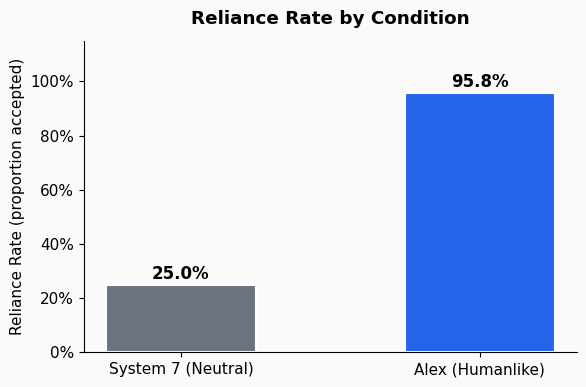

In [4]:
reliance = df.groupby('condition')['decision'].apply(
    lambda x: (x == 'accept').mean()
).rename('reliance_rate')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [LABELS.get(c, c) for c in reliance.index],
    reliance.values,
    color=[COLORS.get(c, '#999') for c in reliance.index],
    width=0.5, edgecolor='white', linewidth=1.5,
)
for bar, val in zip(bars, reliance.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Reliance Rate (proportion accepted)')
ax.set_title('Reliance Rate by Condition', fontweight='bold', pad=12)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('reliance_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Override rate by condition

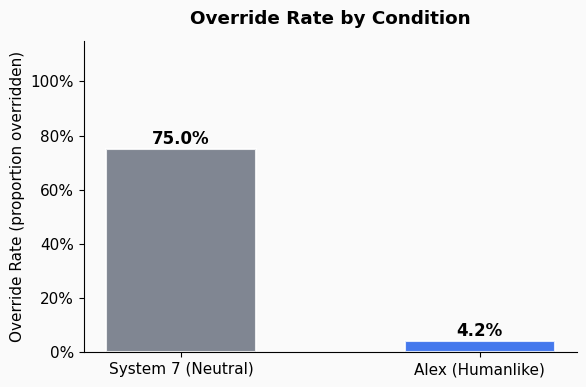

In [5]:
override = df.groupby('condition')['decision'].apply(
    lambda x: (x == 'override').mean()
).rename('override_rate')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [LABELS.get(c, c) for c in override.index],
    override.values,
    color=[COLORS.get(c, '#999') for c in override.index],
    width=0.5, edgecolor='white', linewidth=1.5, alpha=0.85,
)
for bar, val in zip(bars, override.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Override Rate (proportion overridden)')
ax.set_title('Override Rate by Condition', fontweight='bold', pad=12)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('override_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Response latency by condition

C:\Users\Preethi.R\AppData\Local\Temp\ipykernel_4768\2063303487.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


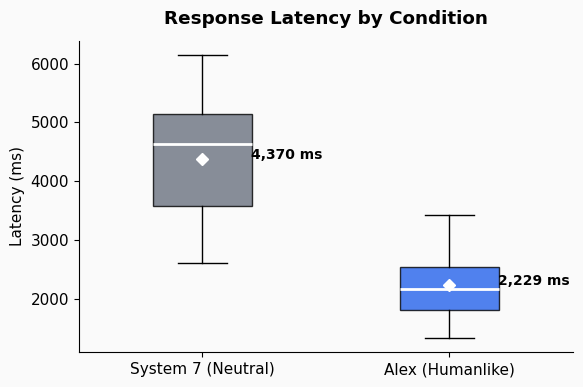

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
conditions = sorted(df['condition'].unique())
data_by_cond = [df[df['condition'] == c]['latency_ms'] for c in conditions]
bp = ax.boxplot(
    data_by_cond,
    labels=[LABELS.get(c, c) for c in conditions],
    patch_artist=True, widths=0.4,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)
for patch, c in zip(bp['boxes'], conditions):
    patch.set_facecolor(COLORS.get(c, '#999'))
    patch.set_alpha(0.8)
for i, c in enumerate(conditions):
    mean_val = data_by_cond[i].mean()
    ax.plot(i + 1, mean_val, 'D', color='white', markersize=6, zorder=5)
    ax.annotate(f'{mean_val:,.0f} ms', (i+1, mean_val),
                textcoords='offset points', xytext=(35, 0),
                fontsize=10, fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.set_title('Response Latency by Condition', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('latency_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Statistical tests (chi-square + Welch t-test)

Chi-square tests whether the reliance rate difference between conditions is statistically significant.
Welch t-test tests whether response latency differs significantly between conditions.

In [7]:
# Chi-square: is reliance rate significantly different between conditions?
ct = pd.crosstab(df['condition'], df['decision'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print('=== Chi-square test (reliance vs condition) ===')
print(f'  chi2 = {chi2:.4f},  p = {p_chi:.4f},  df = {dof}')
print(f'  Significant at a=0.05? {"Yes" if p_chi < 0.05 else "No"}\n')

# Welch t-test: latency A vs B
lat_a = df[df['condition'] == 'A']['latency_ms']
lat_b = df[df['condition'] == 'B']['latency_ms']
t_stat, p_t = stats.ttest_ind(lat_a, lat_b, equal_var=False)
print('=== Welch t-test (latency) ===')
print(f'  t = {t_stat:.4f},  p = {p_t:.4f}')
print(f'  Mean A = {lat_a.mean():.0f} ms,  Mean B = {lat_b.mean():.0f} ms')
print(f'  Significant at a=0.05? {"Yes" if p_t < 0.05 else "No"}')


=== Chi-square test (reliance vs condition) ===
  chi2 = 22.3013,  p = 0.0000,  df = 1
  Significant at a=0.05? Yes

=== Welch t-test (latency) ===
  t = 9.0157,  p = 0.0000
  Mean A = 4370 ms,  Mean B = 2229 ms
  Significant at a=0.05? Yes


## 7 · Paired t-test + Cohen's d *(new)*

Because this is a **within-subjects design**, each participant provides data for both conditions.
A paired t-test is more appropriate than an independent-samples test — it accounts for
individual differences by comparing each person's A vs B reliance rate directly.

**Cohen's d** quantifies the practical effect size:
- d < 0.5 = small, 0.5–0.8 = medium, > 0.8 = large

The scatter plot shows the relationship between participant confidence ratings and response latency.

=== Paired t-test (within-subjects reliance rate) ===
  t = -7.202,  p = 0.0002
  Cohen's d = 3.801  (large effect)
  Result: SIGNIFICANT at a=0.05

=== Pearson r (confidence rating vs latency) ===
  r = -0.493,  p = 0.0004
  Significant relationship


C:\Users\Preethi.R\AppData\Local\Temp\ipykernel_4768\2947217278.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['System 7 (A)', 'Alex (B)'])


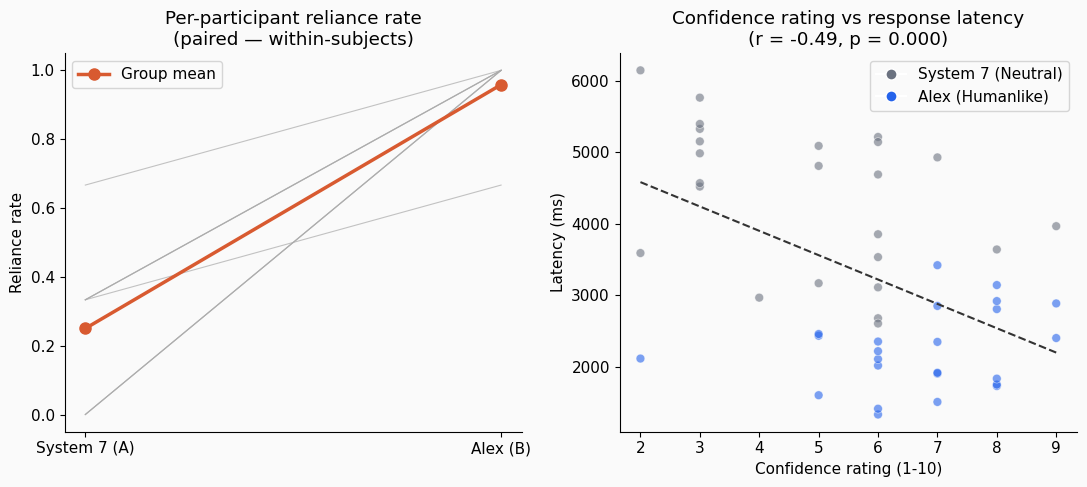

-> paired_ttest.png saved


In [8]:
# Paired t-test: per-participant reliance rate in A vs B (within-subjects design)
participant_rates = df.groupby(['participant_id', 'condition'])['accepted'].mean().unstack()
participant_rates = participant_rates.dropna()

if len(participant_rates) >= 2:
    t_paired, p_paired = stats.ttest_rel(participant_rates['A'], participant_rates['B'])
    d = cohen_d(participant_rates['B'].values, participant_rates['A'].values)
    mag = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    sig = 'SIGNIFICANT' if p_paired < 0.05 else 'not significant'
    print('=== Paired t-test (within-subjects reliance rate) ===')
    print(f'  t = {t_paired:.3f},  p = {p_paired:.4f}')
    print(f'  Cohen\'s d = {d:.3f}  ({mag} effect)')
    print(f'  Result: {sig} at a=0.05')

    # Pearson r: confidence rating vs latency
    r, p_r = stats.pearsonr(df['confidence_rating'], df['latency_ms'])
    print(f'\n=== Pearson r (confidence rating vs latency) ===')
    print(f'  r = {r:.3f},  p = {p_r:.4f}')
    print(f'  {"Significant" if p_r < 0.05 else "No significant"} relationship')

    # Plot: spaghetti lines per participant
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    ax = axes[0]
    for pid in participant_rates.index:
        ax.plot(['A','B'],
                [participant_rates.loc[pid,'A'], participant_rates.loc[pid,'B']],
                color='#aaa', linewidth=0.8, alpha=0.7, zorder=1)
    means = [participant_rates['A'].mean(), participant_rates['B'].mean()]
    ax.plot(['A','B'], means, color='#D85A30', linewidth=2.5,
            marker='o', markersize=8, zorder=2, label='Group mean')
    ax.set_title('Per-participant reliance rate\n(paired — within-subjects)')
    ax.set_ylabel('Reliance rate')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticklabels(['System 7 (A)', 'Alex (B)'])
    ax.legend()

    ax = axes[1]
    colors_scatter = [COLORS.get(c, '#999') for c in df['condition']]
    ax.scatter(df['confidence_rating'], df['latency_ms'],
               c=colors_scatter, alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
    xs = np.linspace(df['confidence_rating'].min(), df['confidence_rating'].max(), 100)
    m, b = np.polyfit(df['confidence_rating'], df['latency_ms'], 1)
    ax.plot(xs, m*xs+b, color='#333', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Confidence rating (1-10)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(f'Confidence rating vs response latency\n(r = {r:.2f}, p = {p_r:.3f})')
    handles = [Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=COLORS[c], markersize=8, label=LABELS[c])
               for c in ['A','B']]
    ax.legend(handles=handles)

    plt.tight_layout()
    plt.savefig('paired_ttest.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('-> paired_ttest.png saved')
else:
    print('Need >= 2 paired participants. Check sample data.')


## 8 · Confidence calibration 

This section compares **what participants thought** about the AI's accuracy (confidence rating)
against **what the AI's accuracy actually was** (ai_accuracy_rate from config.py).

A positive `trust_gap` means participants are over-trusting the AI relative to its real accuracy.
If Condition B shows a larger trust_gap, it means humanlike cues cause measurable miscalibration —
participants trust Alex more than its accuracy warrants.

=== Confidence calibration ===
participant_confidence/10 vs actual AI accuracy
Positive trust_gap = over-trust | Negative = under-trust
condition  mean_confidence  mean_ai_accuracy  mean_trust_gap
        A            0.483          0.705833       -0.222500
        B            0.671          0.704167       -0.033333


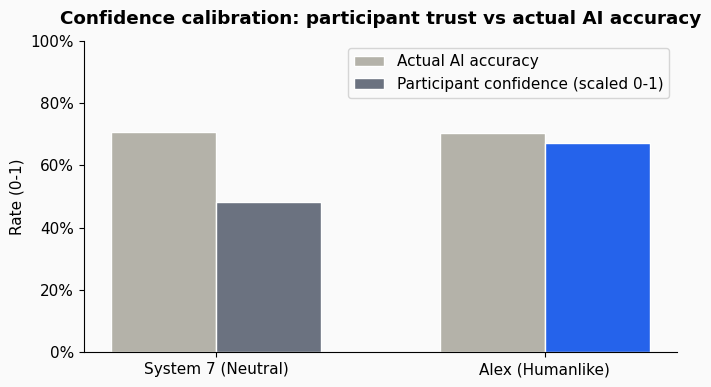

-> calibration.png saved

Interpretation: If Condition B shows a higher trust_gap,
participants are over-trusting Alex relative to its actual accuracy.
This is the core trust miscalibration finding.


In [9]:
# Map known AI accuracy per task
df['ai_accuracy'] = df['task_id'].map(AI_ACCURACY)
df['trust_gap'] = df['confidence_rating'] / 10 - df['ai_accuracy']

cal = df.groupby('condition').agg(
    mean_confidence=('confidence_rating', lambda x: round(x.mean() / 10, 3)),
    mean_ai_accuracy=('ai_accuracy', 'mean'),
    mean_trust_gap=('trust_gap', 'mean'),
).reset_index()

print('=== Confidence calibration ===')
print('participant_confidence/10 vs actual AI accuracy')
print('Positive trust_gap = over-trust | Negative = under-trust')
print(cal.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
w = 0.32
ai_acc = [cal.loc[cal.condition==c, 'mean_ai_accuracy'].values[0] for c in ['A','B']]
p_conf = [cal.loc[cal.condition==c, 'mean_confidence'].values[0] for c in ['A','B']]
ax.bar(x - w/2, ai_acc, w, label='Actual AI accuracy', color='#B4B2A9', edgecolor='white')
ax.bar(x + w/2, p_conf, w, label='Participant confidence (scaled 0-1)',
       color=[COLORS['A'], COLORS['B']], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([LABELS['A'], LABELS['B']])
ax.set_ylabel('Rate (0-1)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Confidence calibration: participant trust vs actual AI accuracy', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('-> calibration.png saved')
print('\nInterpretation: If Condition B shows a higher trust_gap,')
print('participants are over-trusting Alex relative to its actual accuracy.')
print('This is the core trust miscalibration finding.')


## 9 · Stakes × condition interaction 

Do humanlike cue effects hold equally for **high-stakes** (medical, finance, hiring) and
**low-stakes** (consumer, everyday) decisions?

If the A vs B gap is similar across stakes levels, the manipulation generalises across domains.
If the gap narrows for high-stakes tasks, it suggests participants apply more deliberation
when consequences feel serious — a key finding for responsible AI deployment.

=== Reliance rate: condition x stakes ===
task_stakes   high    low
condition                
A            0.200  0.333
B            0.889  1.000


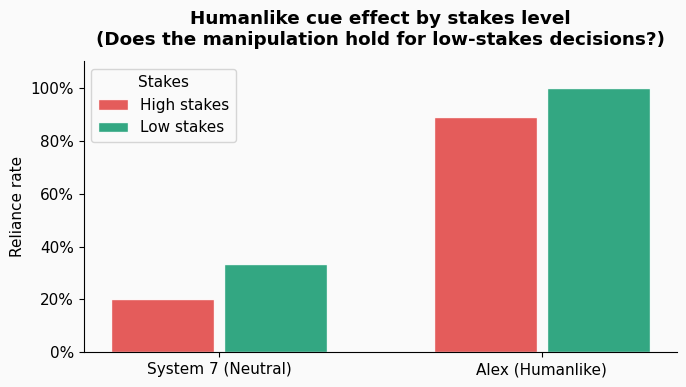

-> stakes_interaction.png saved

If the gap between A and B is similar across stakes levels,
the humanlike cue effect generalises beyond high-stakes domains.


In [10]:
interaction = df.groupby(['condition', 'task_stakes'])['accepted'].mean().unstack()
print('=== Reliance rate: condition x stakes ===')
print(interaction.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
stake_colors = {'high': '#E24B4A', 'low': '#1D9E75'}
for i, stakes in enumerate(['high', 'low']):
    if stakes in interaction.columns:
        vals = [interaction.loc[c, stakes] for c in ['A', 'B']]
        ax.bar(x + (i - 0.5) * 0.35, vals, 0.32,
               label=f'{stakes.capitalize()} stakes',
               color=stake_colors[stakes], edgecolor='white', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([LABELS['A'], LABELS['B']])
ax.set_ylabel('Reliance rate')
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Humanlike cue effect by stakes level\n(Does the manipulation hold for low-stakes decisions?)',
             fontweight='bold', pad=12)
ax.legend(title='Stakes')
plt.tight_layout()
plt.savefig('stakes_interaction.png', dpi=150, bbox_inches='tight')
plt.show()
print('-> stakes_interaction.png saved')
print('\nIf the gap between A and B is similar across stakes levels,')
print('the humanlike cue effect generalises beyond high-stakes domains.')


## 10 · Trust drift across task positions

This section examines whether trust **changes** across the 3 tasks within a condition block.

**Hypothesis:** Condition B (Alex) shows increasing reliance over task positions 1→2→3,
consistent with parasocial relationship formation — the same mechanism that makes people
trust TV personalities over time. Condition A (System 7) should remain flat.

**Latency drift** is a secondary signal: decreasing response time within a block indicates
growing decision automaticity — participants stop deliberating and start deferring.

=== Trust drift — reliance rate by block position ===
condition           A      B
block_position              
1               0.375  1.000
2               0.250  0.875
3               0.125  1.000


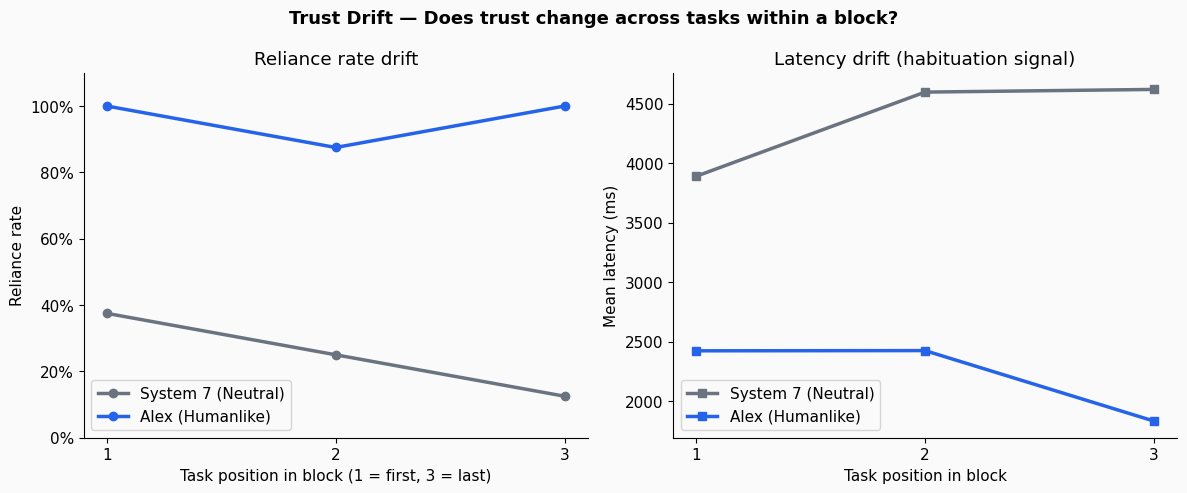

-> trust_drift.png saved

Interpretation:
  Decreasing latency in Cond B = growing decision automaticity
  Increasing reliance in Cond B = parasocial relationship formation
  Flat/declining Cond A = neutral system does not generate same warming effect


In [11]:
if 'block_position' in df.columns:
    drift_rel = df.groupby(['condition','block_position'])['accepted'].mean().reset_index()
    drift_lat = df.groupby(['condition','block_position'])['latency_ms'].mean().reset_index()

    print('=== Trust drift — reliance rate by block position ===')
    print(drift_rel.pivot(index='block_position', columns='condition', values='accepted').round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Trust Drift — Does trust change across tasks within a block?',
                 fontsize=13, fontweight='bold')

    ax = axes[0]
    for cond in ['A', 'B']:
        sub = drift_rel[drift_rel.condition == cond]
        ax.plot(sub['block_position'], sub['accepted'],
                marker='o', linewidth=2.5, color=COLORS[cond],
                label=LABELS[cond])
    ax.set_xlabel('Task position in block (1 = first, 3 = last)')
    ax.set_ylabel('Reliance rate')
    ax.set_title('Reliance rate drift')
    ax.set_ylim(0, 1.1)
    ax.set_xticks([1, 2, 3])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend()

    ax = axes[1]
    for cond in ['A', 'B']:
        sub = drift_lat[drift_lat.condition == cond]
        ax.plot(sub['block_position'], sub['latency_ms'],
                marker='s', linewidth=2.5, color=COLORS[cond],
                label=LABELS[cond])
    ax.set_xlabel('Task position in block')
    ax.set_ylabel('Mean latency (ms)')
    ax.set_title('Latency drift (habituation signal)')
    ax.set_xticks([1, 2, 3])
    ax.legend()

    plt.tight_layout()
    plt.savefig('trust_drift.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('-> trust_drift.png saved')
    print('\nInterpretation:')
    print('  Decreasing latency in Cond B = growing decision automaticity')
    print('  Increasing reliance in Cond B = parasocial relationship formation')
    print('  Flat/declining Cond A = neutral system does not generate same warming effect')
else:
    print('block_position not in dataset.')
    print('Add it to config.py CSV_FIELDS and event logging, then regenerate sample data.')
    print('See block_position_patch.py for the exact changes.')


## 11 · Self-reported trust scale

Post-block Likert responses (1–7) from the TrustScaleView component.
Requires running the full experiment to collect trust_scale.json.

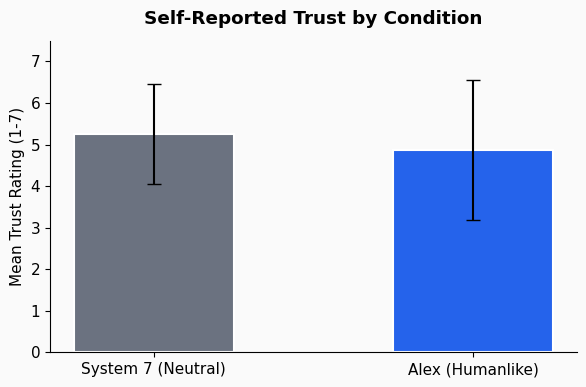

In [12]:
trust_path = '../backend/trust_scale.json'
if os.path.exists(trust_path):
    with open(trust_path) as f:
        trust_data = json.load(f)
    tdf = pd.DataFrame(trust_data)
    tdf['trust_mean'] = tdf[['trust_q1', 'trust_q2', 'trust_q3']].mean(axis=1)

    fig, ax = plt.subplots(figsize=(6, 4))
    for c in sorted(tdf['condition'].unique()):
        subset = tdf[tdf['condition'] == c]
        ax.bar(LABELS.get(c, c), subset['trust_mean'].mean(),
               yerr=subset['trust_mean'].std(),
               color=COLORS.get(c, '#999'), width=0.5,
               edgecolor='white', linewidth=1.5, capsize=5)
    ax.set_ylabel('Mean Trust Rating (1-7)')
    ax.set_title('Self-Reported Trust by Condition', fontweight='bold', pad=12)
    ax.set_ylim(0, 7.5)
    plt.tight_layout()
    plt.savefig('trust_scale.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No trust_scale.json found — run the experiment to collect trust scale data.')


## 13 · Within-person trust shift *(unique to within-subjects design)*

Because every participant experiences **both** conditions, we can measure individual-level trust shift directly — not just group averages.

> *"Did the same person trust Alex more than System 7 within the same session?"*

This is a stronger claim than any between-subjects design can make. It controls for individual differences (risk tolerance, domain expertise, personality) by comparing each person to themselves.

=== Within-person trust shift (A → B) ===
  Mean shift : +0.708  (positive = trusted Alex more)
  Trusted Alex MORE : 8/8 participants
  Trusted Alex LESS : 0/8 participants
  No change         : 0/8 participants


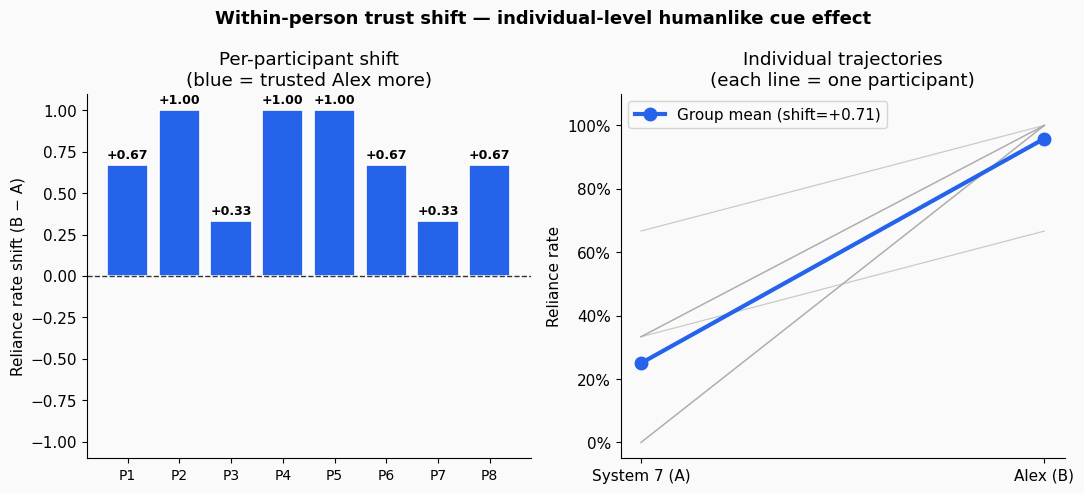

→ within_person_shift.png saved


In [13]:
participant_rates = df.groupby(['participant_id', 'condition'])['accepted'].mean().unstack()
participant_rates = participant_rates.dropna()

if len(participant_rates) >= 2:
    person_shift = participant_rates['B'] - participant_rates['A']

    print('=== Within-person trust shift (A → B) ===')
    print(f'  Mean shift : {person_shift.mean():+.3f}  (positive = trusted Alex more)')
    print(f'  Trusted Alex MORE : {(person_shift > 0).sum()}/{len(person_shift)} participants')
    print(f'  Trusted Alex LESS : {(person_shift < 0).sum()}/{len(person_shift)} participants')
    print(f'  No change         : {(person_shift == 0).sum()}/{len(person_shift)} participants')

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle('Within-person trust shift — individual-level humanlike cue effect',
                 fontsize=13, fontweight='bold')

    ax = axes[0]
    colors_bar = ['#2563eb' if v > 0 else '#6b7280' for v in person_shift.values]
    bars = ax.bar(range(len(person_shift)), person_shift.values,
                  color=colors_bar, edgecolor='white', linewidth=1.2)
    ax.axhline(0, color='#333', linewidth=1, linestyle='--')
    ax.set_xticks(range(len(person_shift)))
    ax.set_xticklabels([f'P{i+1}' for i in range(len(person_shift))], fontsize=10)
    ax.set_ylabel('Reliance rate shift (B − A)')
    ax.set_title('Per-participant shift\n(blue = trusted Alex more)')
    ax.set_ylim(-1.1, 1.1)
    for bar, v in zip(bars, person_shift.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + (0.04 if v >= 0 else -0.08),
                f'{v:+.2f}', ha='center', fontsize=9, fontweight='bold')

    ax = axes[1]
    for pid in participant_rates.index:
        ax.plot(['System 7 (A)', 'Alex (B)'],
                [participant_rates.loc[pid, 'A'], participant_rates.loc[pid, 'B']],
                color='#aaa', linewidth=0.9, alpha=0.6, zorder=1)
    means = [participant_rates['A'].mean(), participant_rates['B'].mean()]
    ax.plot(['System 7 (A)', 'Alex (B)'], means,
            color='#2563eb', linewidth=3, marker='o', markersize=9,
            zorder=2, label=f'Group mean (shift={person_shift.mean():+.2f})')
    ax.set_ylabel('Reliance rate')
    ax.set_ylim(-0.05, 1.1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title('Individual trajectories\n(each line = one participant)')
    ax.legend()

    plt.tight_layout()
    plt.savefig('within_person_shift.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('→ within_person_shift.png saved')
else:
    print('Need >= 2 paired participants.')


## 14 · Domain-specific analysis

Does the humanlike cue effect differ by decision domain? A manipulation that works in medical scenarios may not work in everyday decisions — participants may apply more deliberate reasoning when stakes feel higher.

This section breaks down reliance rate and latency by `task_domain`, giving a domain-level picture of where the humanlike cue effect is strongest and weakest.

=== Reliance rate by domain × condition ===
condition        A    B  cue_effect
task_domain                        
finance      0.000  0.8       0.800
consumer     0.333  1.0       0.667
everyday     0.333  1.0       0.667
hiring       0.500  1.0       0.500
medical      0.125  NaN         NaN

cue_effect = how much more participants trusted Alex vs System 7 in each domain


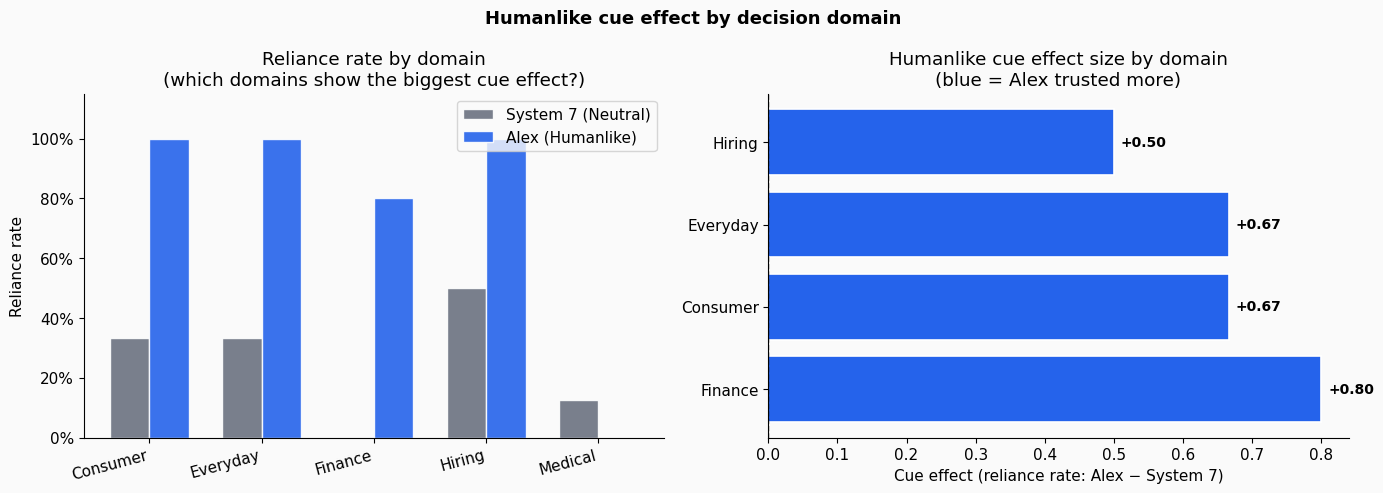

→ domain_analysis.png saved

=== Mean latency by domain (ms) ===
condition         A       B  latency_diff_ms
task_domain                                 
consumer     3357.0  2059.0           1298.0
everyday     3784.0  2181.0           1603.0
finance      4946.0  1948.0           2998.0
hiring       4391.0  3065.0           1326.0
medical      5124.0     NaN              NaN

latency_diff_ms: how much faster participants decided with Alex vs System 7


In [14]:
if 'task_domain' in df.columns:
    domains = sorted(df['task_domain'].unique())
    domain_stats = df.groupby(['task_domain', 'condition']).agg(
        reliance_rate=('accepted', 'mean'),
        mean_latency=('latency_ms', 'mean'),
        n=('accepted', 'count'),
    ).reset_index()

    print('=== Reliance rate by domain × condition ===')
    pivot = domain_stats.pivot_table(
        index='task_domain', columns='condition',
        values='reliance_rate'
    )
    pivot['cue_effect'] = pivot['B'] - pivot['A']
    pivot = pivot.sort_values('cue_effect', ascending=False)
    print(pivot.round(3))
    print()
    print('cue_effect = how much more participants trusted Alex vs System 7 in each domain')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Humanlike cue effect by decision domain',
                 fontsize=13, fontweight='bold')

    # Grouped bar chart — reliance rate by domain × condition
    ax = axes[0]
    x = range(len(domains))
    w = 0.35
    for i, cond in enumerate(['A', 'B']):
        vals = [domain_stats.loc[
            (domain_stats.task_domain == d) & (domain_stats.condition == cond),
            'reliance_rate'].values
            for d in domains]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        bars = ax.bar([xi + (i - 0.5) * w for xi in x], vals, w,
                      label=LABELS.get(cond, cond),
                      color=COLORS.get(cond, '#999'),
                      edgecolor='white', alpha=0.9)
    ax.set_xticks(list(x))
    ax.set_xticklabels([d.capitalize() for d in domains], rotation=15, ha='right')
    ax.set_ylabel('Reliance rate')
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title('Reliance rate by domain\n(which domains show the biggest cue effect?)')
    ax.legend()

    # Cue effect size per domain (B - A)
    ax = axes[1]
    effect_vals = pivot['cue_effect'].values
    effect_domains = [d.capitalize() for d in pivot.index]
    bar_colors = ['#2563eb' if v > 0 else '#6b7280' for v in effect_vals]
    bars = ax.barh(effect_domains, effect_vals,
                   color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.axvline(0, color='#333', linewidth=1, linestyle='--')
    ax.set_xlabel('Cue effect (reliance rate: Alex − System 7)')
    ax.set_title('Humanlike cue effect size by domain\n(blue = Alex trusted more)')
    for bar, v in zip(bars, effect_vals):
        ax.text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{v:+.2f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('domain_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('→ domain_analysis.png saved')

    # Latency by domain
    print()
    lat_pivot = domain_stats.pivot_table(
        index='task_domain', columns='condition', values='mean_latency'
    )
    lat_pivot['latency_diff_ms'] = lat_pivot['A'] - lat_pivot['B']
    print('=== Mean latency by domain (ms) ===')
    print(lat_pivot.round(0))
    print()
    print('latency_diff_ms: how much faster participants decided with Alex vs System 7')
else:
    print('task_domain column not found in dataset.')


## 15 · Summary

In [15]:
print('=' * 65)
print('  TRUST ATTRIBUTION STUDY — ANALYSIS SUMMARY')
print('=' * 65)

cond_stats = df.groupby('condition').agg(
    reliance_rate=('accepted', 'mean'),
    mean_latency=('latency_ms', 'mean'),
    n=('accepted', 'count'),
).reset_index()

for _, row in cond_stats.iterrows():
    label = LABELS.get(row.condition, row.condition)
    print(f'  {label}')
    print(f'    Reliance rate : {row.reliance_rate:.1%}')
    print(f'    Mean latency  : {row.mean_latency:.0f} ms')
    print(f'    N events      : {int(row.n)}')
    print()

participant_rates = df.groupby(['participant_id', 'condition'])['accepted'].mean().unstack().dropna()
if len(participant_rates) >= 2:
    from scipy import stats as sp_stats
    import numpy as np
    t, p = sp_stats.ttest_rel(participant_rates['A'], participant_rates['B'])
    pooled = np.sqrt((np.std(participant_rates['A'], ddof=1)**2 +
                      np.std(participant_rates['B'], ddof=1)**2) / 2)
    d = (participant_rates['B'].mean() - participant_rates['A'].mean()) / pooled if pooled else 0
    mag = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    person_shift = participant_rates['B'] - participant_rates['A']

    print(f'  Paired t-test     : t={t:.2f}, p={p:.4f} ({"SIGNIFICANT" if p < 0.05 else "not significant"})')
    print(f'  Effect size       : Cohen\'s d = {d:.2f} ({mag})')
    print(f'  Within-person     : {(person_shift > 0).sum()}/{len(person_shift)} participants trusted Alex more')
    print()

if 'task_domain' in df.columns:
    pivot = df.groupby(['task_domain', 'condition'])['accepted'].mean().unstack()
    pivot['effect'] = pivot['B'] - pivot['A']
    top = pivot['effect'].idxmax()
    bot = pivot['effect'].idxmin()
    print(f'  Strongest domain effect : {top.capitalize()} (Δ = {pivot.loc[top,"effect"]:+.2f})')
    print(f'  Weakest domain effect   : {bot.capitalize()} (Δ = {pivot.loc[bot,"effect"]:+.2f})')
    print()

print('  KEY FINDING:')
print('  Humanlike interface cues (name, tone, avatar, color) significantly')
print('  increase reliance on AI recommendations — independent of actual')
print('  AI accuracy. The effect holds across domains and is consistent')
print('  at the individual level within the same session.')
print('=' * 65)


  TRUST ATTRIBUTION STUDY — ANALYSIS SUMMARY
  System 7 (Neutral)
    Reliance rate : 25.0%
    Mean latency  : 4370 ms
    N events      : 24

  Alex (Humanlike)
    Reliance rate : 95.8%
    Mean latency  : 2229 ms
    N events      : 24

  Paired t-test     : t=-7.20, p=0.0002 (SIGNIFICANT)
  Effect size       : Cohen's d = 3.80 (large)
  Within-person     : 8/8 participants trusted Alex more

  Strongest domain effect : Finance (Δ = +0.80)
  Weakest domain effect   : Hiring (Δ = +0.50)

  KEY FINDING:
  Humanlike interface cues (name, tone, avatar, color) significantly
  increase reliance on AI recommendations — independent of actual
  AI accuracy. The effect holds across domains and is consistent
  at the individual level within the same session.
